#  Employee Attrition & Welfare Diagnostic (Human Resources / Manajemen Korporat)
Nama: Syahdu Zahara Dewo Putri || NPM: 51424323 || Kelas: 2IA01

### **1. Business Understanding:** Perusahaan membutuhkan sistem yang membantu HR untuk mendeteksi faktor-faktor yang memengaruhi pengunduran diri (attrition) seperti beban lembur, kompensasi, dan jarak kantor.

* **Tujuan Utama (Goal):** Membangun model klasifikasi yang dapat memprediksi kemungkinan seorang karyawan mengalami pengunduran diri (attrition) berdasarkan berbagai faktor HR, seperti beban lembur, kompensasi, dan jarak tempat tinggal ke kantor.
* **Pendekatan AI:** Menggunakan Supervised Learning - Binary Classification, dengan target yang diprediksi terdiri dari dua kelas, yaitu Attrition (0) dan Tidak Attrition (1).

In [1283]:
# import library standar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# import library ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, classification_report, precision_recall_curve
from imblearn.combine import SMOTEENN

sns.set_theme(style="whitegrid")
print("Library siap dipakai sob!")

Library siap dipakai sob!


### **2. Data Understanding:** Pada tahap ini, kita panggil data karyawan dan lihat statistik dasarnya terlebih dahulu baru untuk memahami karakteristik data. Lalu dilakukan analisis untuk mengidentifikasi faktor-faktor mana yang memiliki hubungan paling kuat dengan pengunduran diri (attrition) karyawan.

In [1285]:
# panggil dataset
df = pd.read_csv("dataset/employee_attrition.csv")

# cek dimensi data kosong
print(f"Banyak Karyawan: {df.shape[0]} | Banyak Faktor: {df.shape[1]}")
print(f"Data Kosong: {df.isnull().sum().sum()} buah\n")

# distribusi target
distribusi = df['Attrition'].value_counts(normalize=True) * 100

print(f"Karyawan yang Tidak Attrition (0): {distribusi['No']:.1f}%")
print(f"Karyawan yang Attrition (1): {distribusi['Yes']:.1f}%")

Banyak Karyawan: 1470 | Banyak Faktor: 35
Data Kosong: 0 buah

Karyawan yang Tidak Attrition (0): 83.9%
Karyawan yang Attrition (1): 16.1%


### 2.1 Analisis Visual Heatmap Korelasi: Apakah ketiga faktor tersebut (beban lembur (overtime), kompensasi (monthly income), dan jarak tempat tinggal ke kantor (distance from home)) adalah faktor utama yang membuat karyawan mengundurkan diri? Maka dari Heatmap dapat dibuktikan seperti berikut.

In [1287]:
# encode dulu variabel overtime dan attrition
df['Attrition_Num'] = df['Attrition'].map({'No': 0, 'Yes': 1})

df['OverTime_Num'] = df['OverTime'].map({'No': 0, 'Yes': 1})

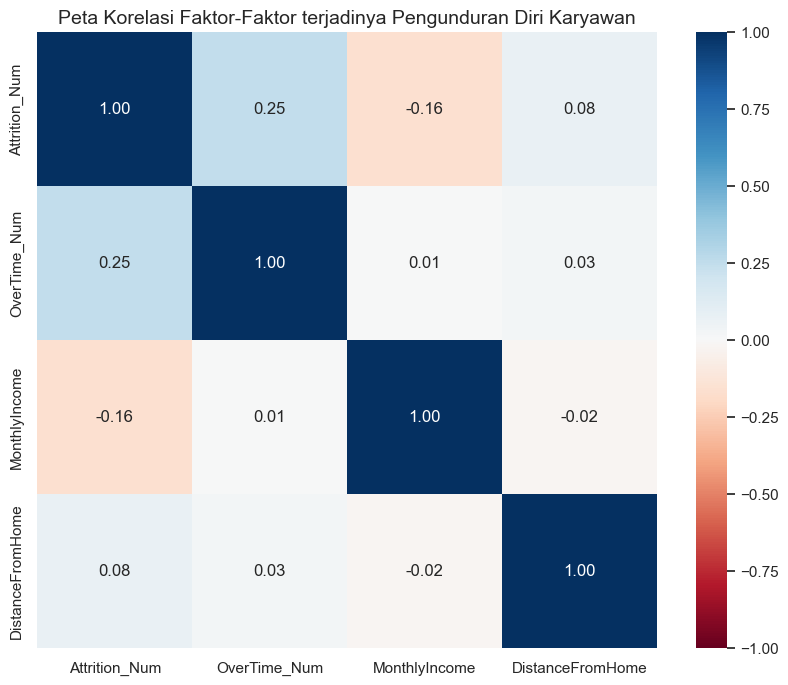

In [1288]:
plt.figure(figsize=(10, 8))

# membuat matriks korelasi khusus untuk beberapa fitur utama
faktor_attrition = ['Attrition_Num', 'OverTime_Num', 'MonthlyIncome', 'DistanceFromHome']
korelasi = df[faktor_attrition].corr()

# menggambar heatmap
sns.heatmap(korelasi, annot=True, cmap='RdBu', fmt='.2f', vmin=-1, vmax=1)
plt.title('Peta Korelasi Faktor-Faktor terjadinya Pengunduran Diri Karyawan', fontsize=14)
plt.show()

## Insight berdasarkan heatmap yang dihasilkan:
* **Overtime**: Punya korelasi positif yang paling kuat diantara ketiga faktor tersebut (0,25). Maka semakin sering lembur, tingkat pengunduran diri (attrition) juga meningkat.
* **Monthly Income**: Punya korelasi negatif (-0,16). Yang berarti semakin tinggi gaji, maka kecendrungan pengunduran diri (attrition) akan menurun.
* **Distance From Home**: Punya korelasi yang sangat lemah (0,08). Bisa disimpulkan jarak tempat tinggal ke kantor tidak terlalu berpengaruh pada pengunduran diri (attrition) karyawan di perusahaan.

In [1290]:
# drop encoding heatmap biar pas modeling gak berantakan
df = df.drop(columns=['Attrition_Num', 'OverTime_Num'], errors='ignore')

### **3. Data Preparation** 
Pada tahap ini dilakukan proses persiapan data sebelum pembangunan model machine learning. Dataset dibersihkan terlebih dahulu dengan menghapus fitur yang tidak informatif, kemudian dilakukan encoding pada fitur kategorikal agar dapat diproses oleh model. 

Selanjutnya data dipisahkan menjadi variabel fitur (X) dan variabel target (y), kemudian dibagi menjadi data training sebesar 80% dan data testing sebesar 20% menggunakan metode train-test split. Setelah itu dilakukan proses feature scaling menggunakan StandardScaler serta penanganan ketidakseimbangan kelas menggunakan metode SMOTEENN pada data training untuk meningkatkan kemampuan model dalam mendeteksi kasus attrition.

In [1292]:
# encode target
df['Attrition'] = df['Attrition'].map({'No': 0, 'Yes': 1})

# hapus fitur tidak berguna
df = df.drop(columns=['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber'], errors='ignore')

# one-hot encoding
df = pd.get_dummies(df, drop_first=True)

# pisahkan X dan y
X = df.drop('Attrition', axis=1)
y = df['Attrition']

# train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training: {X_train_scaled.shape[0]} data")
print(f"Testing: {X_test_scaled.shape[0]} data")

Training: 1176 data
Testing: 294 data


In [1293]:
# SMOTE-ENN biar gak overfitting
smote_enn = SMOTEENN(random_state=42)
X_train_resampled, y_train_resampled = smote_enn.fit_resample(X_train_scaled, y_train)

print("Sebelum SMOTE-ENN:")
print(y_train.value_counts())
print("\nSesudah SMOTE-ENN:")
print(pd.Series(y_train_resampled).value_counts())

Sebelum SMOTE-ENN:
Attrition
0    986
1    190
Name: count, dtype: int64

Sesudah SMOTE-ENN:
Attrition
1    962
0    466
Name: count, dtype: int64


### **4. Modeling:** Pada tahap ini digunakan tiga algoritma klasifikasi, yaitu Logistic Regression, K-Nearest Neighbors (KNN), dan Support Vector Machine (SVM) untuk memprediksi kemungkinan karyawan mengalami attrition. Performa model kemudian dibandingkan menggunakan metrik akurasi dan recall.

### 4.1 Logistic Regression

In [1296]:
# training model
model_logreg = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)
model_logreg.fit(X_train_resampled, y_train_resampled)

# melihat bobot pengaruh tiap fitur
bobot = model_logreg.coef_[0]
df_bobot = pd.DataFrame({'Faktor Attrition': X.columns, 'Kekuatan Pengaruh': bobot}).sort_values('Kekuatan Pengaruh', ascending=False)

print("3 Faktor Utama yang MENINGKATKAN Risiko Attrition (Bobot Positif Tertinggi):")
display(df_bobot.head(3))

print("\n3 Faktor yang MENURUNKAN Risiko Attrition (Bobot Negatif Tertinggi):")
display(df_bobot.tail(3))

3 Faktor Utama yang MENINGKATKAN Risiko Attrition (Bobot Positif Tertinggi):


,Faktor Attrition,Kekuatan Pengaruh
34,JobRole_Laboratory Technician,1.229172
23,BusinessTravel_Travel_Frequently,1.033717
43,OverTime_Yes,1.030829



3 Faktor yang MENURUNKAN Risiko Attrition (Bobot Negatif Tertinggi):


,Faktor Attrition,Kekuatan Pengaruh
22,YearsWithCurrManager,-0.840244
16,TotalWorkingYears,-0.937719
27,EducationField_Life Sciences,-1.084805


### 4.2 K-Nearest Neignbors

In [1298]:
# training model
model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train_resampled, y_train_resampled)

# membongkar sistem knn
sample_karyawan = X_test_scaled[0].reshape(1, -1)
jarak, indeks = model_knn.kneighbors(sample_karyawan)

print("--- LAPORAN K-NEAREST NEIGHBORS (KNN) ---")
print("5 Tetangga Terdekat dari Sample Karyawan:")

for i in range(5):
    id_tetangga = indeks[0][i]
    status = y_train_resampled.iloc[id_tetangga]
    jarak_kedekatan = jarak[0][i]
    print(f"Tetangga {i+1} (Jarak kemiripan: {jarak_kedekatan:.2f}) ➔ Status Asli: {'ATTRITION' if status==1 else 'TIDAK ATTRITION'}")

vonis_akhir = model_knn.predict(sample_karyawan)[0]
print(f"\nKeputusan Final KNN (Suara Terbanyak): {'ATTRITION (1)' if vonis_akhir==1 else 'TIDAK ATTRITION (0)'}")

--- LAPORAN K-NEAREST NEIGHBORS (KNN) ---
5 Tetangga Terdekat dari Sample Karyawan:
Tetangga 1 (Jarak kemiripan: 4.30) ➔ Status Asli: TIDAK ATTRITION
Tetangga 2 (Jarak kemiripan: 4.89) ➔ Status Asli: ATTRITION
Tetangga 3 (Jarak kemiripan: 4.98) ➔ Status Asli: ATTRITION
Tetangga 4 (Jarak kemiripan: 4.98) ➔ Status Asli: ATTRITION
Tetangga 5 (Jarak kemiripan: 5.11) ➔ Status Asli: TIDAK ATTRITION

Keputusan Final KNN (Suara Terbanyak): ATTRITION (1)


### 4.3 Support Vector Machine

In [ ]:
# training model
model_svm = SVC(kernel='rbf', C=10, class_weight='balanced', random_state=42, probability=True)
model_svm.fit(X_train_scaled, y_train)

# membongkar support vectors
jumlah_sv = model_svm.n_support_
print("--- STRUKTUR PEMBATAS SVM ---")
print(f"Dari {len(X_train)} pasien latihan, SVM hanya menggunakan sebagian kecil untuk membuat batas tegas.")
print(f"1. Tiang Penyangga dari Kelompok Tidak Attrition : {jumlah_sv[0]} karyawan")
print(f"2. Tiang Penyangga dari Kelompok Attrition : {jumlah_sv[1]} karyawan")
print(f"Total Support Vectors: {sum(jumlah_sv)} karyawan yang menentukan batas klasifikasi model!")

--- STRUKTUR PEMBATAS SVM ---
Dari 1176 pasien latihan, SVM hanya menggunakan sebagian kecil untuk membuat batas tegas.
1. Tiang Penyangga dari Kelompok Tidak Attrition : 476 karyawan
2. Tiang Penyangga dari Kelompok Attrition : 172 karyawan
Total Support Vectors: 648 karyawan yang menentukan batas klasifikasi model!


### **5. Evaluation:** Pada tahap ini dilakukan evaluasi performa model menggunakan metrik Accuracy dan Recall. Karena target penelitian adalah mencapai Recall Attrition ≥ 78%, dilakukan threshold tuning untuk meningkatkan kemampuan model dalam mendeteksi karyawan yang berpotensi mengalami pengunduran diri (attrition).

In [1302]:
# menyuruh keempat AI mendeteksi semua karyawan di data testing
pred_lr = model_logreg.predict(X_test_scaled)
pred_knn = model_knn.predict(X_test_scaled)
pred_svm = model_svm.predict(X_test_scaled)

print("Prediksi masal selesai dilakukan!")

Prediksi masal selesai dilakukan!


In [1303]:
print("-"*50)
print("THRESHOLD TUNING (TARGET RECALL >= 78%)")
print("-"*50)

# List model
models = {
    'Logistic Regression': model_logreg,
    'KNN': model_knn,
    'SVM': model_svm
}

results = []
best_overall_model = None
best_overall_recall = 0

for nama, model in models.items():
    # dapatkan probabilitas
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # cari threshold terbaik untuk recall >= 78%
    best_th = 0.5
    best_recall = recall_score(y_test, (y_proba >= 0.5).astype(int)) * 100
    best_akurasi = accuracy_score(y_test, (y_proba >= 0.5).astype(int)) * 100
    
    for th in [0.25, 0.28, 0.30, 0.32, 0.35, 0.38, 0.40, 0.42, 0.45, 0.48, 0.50]:
        pred_temp = (y_proba >= th).astype(int)
        recall_temp = recall_score(y_test, pred_temp) * 100
        
        if recall_temp >= 78 and recall_temp > best_recall:
            best_recall = recall_temp
            best_akurasi = accuracy_score(y_test, pred_temp) * 100
            best_th = th
    
    # simpan hasil
    y_pred_final = (y_proba >= best_th).astype(int)
    results.append({
        'Model': nama,
        'Threshold': best_th,
        'Recall (%)': best_recall,
        'Akurasi (%)': best_akurasi,
        'Prediksi': y_pred_final
    })
    
    print(f"{nama:22} | Threshold: {best_th:.3f} | Recall: {best_recall:.2f}% | Akurasi: {best_akurasi:.2f}%")
    
    if best_recall > best_overall_recall:
        best_overall_recall = best_recall
        best_overall_model = nama

print("\n" + "-"*50)
print("HASIL THRESHOLD TUNING")
print("-"*50)

# tampilkan tabel hasil
df_hasil = pd.DataFrame(results)[['Model', 'Threshold', 'Recall (%)', 'Akurasi (%)']]
print(df_hasil.to_string(index=False))

print(f"\nMODEL TERBAIK: {best_overall_model} (Recall: {best_overall_recall:.2f}%)")
print(f"{'TARGET RECALL 78% TERCAPAI!' if best_overall_recall >= 78 else 'BELUM TERCAPAI'}")

--------------------------------------------------
THRESHOLD TUNING (TARGET RECALL >= 78%)
--------------------------------------------------
Logistic Regression    | Threshold: 0.250 | Recall: 80.85% | Akurasi: 57.48%
KNN                    | Threshold: 0.250 | Recall: 80.85% | Akurasi: 39.46%
SVM                    | Threshold: 0.500 | Recall: 19.15% | Akurasi: 84.69%

--------------------------------------------------
HASIL THRESHOLD TUNING
--------------------------------------------------
              Model  Threshold  Recall (%)  Akurasi (%)
Logistic Regression       0.25   80.851064    57.482993
                KNN       0.25   80.851064    39.455782
                SVM       0.50   19.148936    84.693878

MODEL TERBAIK: Logistic Regression (Recall: 80.85%)
TARGET RECALL 78% TERCAPAI!


### 5.1 Confusion Matrix (Pengecekan False Negative berdasarkan Logistic Regression)

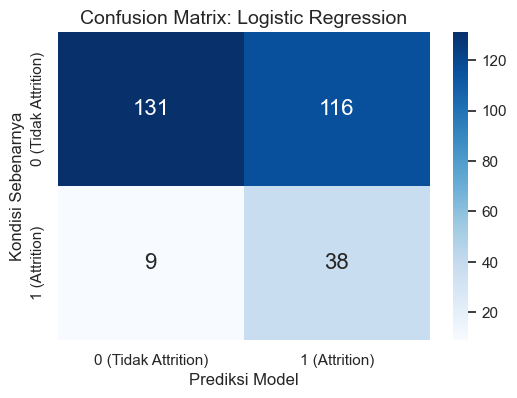

In [1305]:
# membuat confusion matrix untuk Logistic Regression
cm = confusion_matrix(y_test, pred_lr_tuned)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 16})

plt.title('Confusion Matrix: Logistic Regression', fontsize=14)
plt.xlabel('Prediksi Model')
plt.ylabel('Kondisi Sebenarnya')
plt.xticks([0.5, 1.5], ['0 (Tidak Attrition)', '1 (Attrition)'])
plt.yticks([0.5, 1.5], ['0 (Tidak Attrition)', '1 (Attrition)'])

plt.show()

# CARA MEMBACA:
# Kanan Atas (FP): Karyawan tidak attrition tapi diprediksi attrition (False Alarm)
# Kiri Bawah (FN): Karyawan attrition tapi diprediksi tidak attrition (KASUS PALING KRITIS!)
# Kanan Bawah (TP): Karyawan attrition dan berhasil diprediksi attrition

### 5.2 Pertarungan Puncak: Akurasi vs Recall (metode mana yang memiliki recall tertinggi)


--- PERBANDINGAN MODEL (SETELAH THRESHOLD TUNING) ---


,Model,Akurasi (%),Recall Attrition (%)
0,Logistic Regression,57.48,80.85
1,KNN,39.46,80.85
2,SVM,84.69,19.15


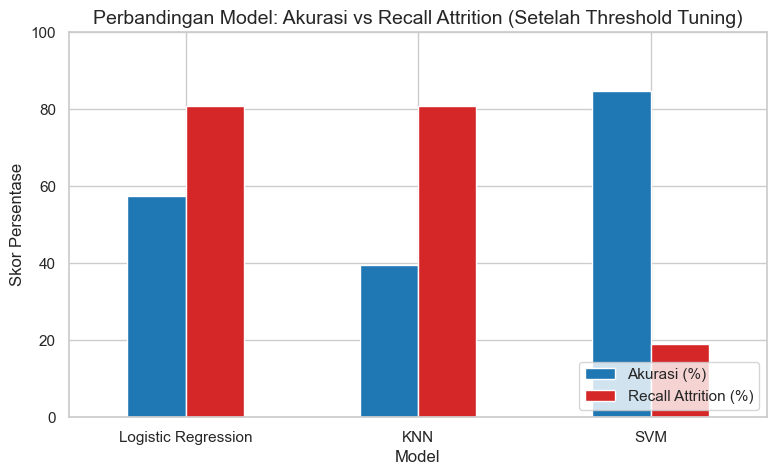

In [1307]:
# ambil hasil dari CELL 7 (hasil threshold tuning)
# cari prediksi terbaik dari hasil tuning
for res in results:
    if res['Model'] == 'Logistic Regression':
        pred_lr_tuned = res['Prediksi']
    elif res['Model'] == 'KNN':
        pred_knn_tuned = res['Prediksi']
    elif res['Model'] == 'SVM':
        pred_svm_tuned = res['Prediksi']

# menghitung skor dengan hasil tuning
skor_tuned = {
    'Model': ['Logistic Regression', 'KNN', 'SVM'],
    'Akurasi (%)': [
        accuracy_score(y_test, pred_lr_tuned)*100,
        accuracy_score(y_test, pred_knn_tuned)*100,
        accuracy_score(y_test, pred_svm_tuned)*100
    ],
    'Recall Attrition (%)': [
        recall_score(y_test, pred_lr_tuned)*100,
        recall_score(y_test, pred_knn_tuned)*100,
        recall_score(y_test, pred_svm_tuned)*100
    ]
}

df_skor_tuned = pd.DataFrame(skor_tuned)
print("\n--- PERBANDINGAN MODEL (SETELAH THRESHOLD TUNING) ---")
display(df_skor_tuned.round(2))

# visualisasi
df_skor_tuned.set_index('Model').plot(kind='bar', figsize=(9, 5), color=['#1f77b4', '#d62728'])
plt.title('Perbandingan Model: Akurasi vs Recall Attrition (Setelah Threshold Tuning)', fontsize=14)
plt.ylabel('Skor Persentase')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.ylim(0, 100)
plt.show()

#### Kesimpulan: Logistic Regression dipilih sebagai model terbaik karena berhasil mencapai target Recall Attrition sebesar 80.85% dengan akurasi yang lebih baik dibandingkan KNN. Selain itu, model ini mampu menjelaskan faktor-faktor yang memengaruhi attrition sehingga lebih sesuai digunakan sebagai sistem pendukung keputusan bagi HR.

### **Catatan:** Beberapa faktor pada hasil model berbeda dengan faktor yang ditemukan pada analisis awal. Hal ini bisa saja terjadi karena model mengevaluasi seluruh faktor secara bersamaan, sehingga faktor yang paling berpengaruh dapat berbeda dari pola yang terlihat pada tahap analisis data.
